In [1]:
import time
notebook_start = time.perf_counter()

%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import json, feos, si_units as si, numpy as np, importlib.metadata
import thermoift.PLOT_SETTINGS as ps
from thermoift import KIJ
from pathlib import Path
from itertools import combinations
from thermoift.FeosPlugin import (
    RegistryManager,
    CompositionHandler,
    ParameterBuilder,
    PropertyCalculator,
    VLECalculator,
    InterfacialTensionCalculator,
    DataProcessor,
    PlottingEngine
)
from thermoift.semi_emperical_correlations import semi_emperical_correlations

print(f"FEOS version used: {importlib.metadata.version('feos')}")
KIJ_DIR = Path(KIJ.__file__).parent

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift


  Installing build dependencies ... -

 \

 |

 done


...

 done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1721 sha256=21196c409edb7370c93e0f896fbba3e5aef6b3236976dca457915925f2d0bac7
  Stored in directory: /tmp/pip-ephem-wheel-cache-wy4qcctd/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift


  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:


ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/home/darshan/A6/py_A6/lib/python3.12/site-packages/__editable__.thermoift-0.2.0.pth'



Note: you may need to restart the kernel to use updated packages.


FEOS version used: 0.9.4


## Cell 2: BATCH RUN with PARAMETER tag

In [2]:
SLURM_RUN    = False
FEED_INDEX   = None  # Set via papermill for SLURM array jobs (e.g., -p FEED_INDEX 5)
verbose      = False
CSV_FOLDER   = "CSV"
PLOT_FOLDER  = "PLOTS"

In [3]:
# Parameters
FEED_INDEX = 22
SLURM_RUN = True
verbose = False
CSV_FOLDER = "1682392_22/CSV"
PLOT_FOLDER = "1682392_22/PLOTS"


## Cell 3: Load the feed componenets and their compositions from the CSV file

In [4]:
csv_path         = "CSV_feeds/Combined_compositions.csv"
COMPONENTS       = RegistryManager.map_csv_to_components()
all_compositions = CompositionHandler.load_compositions(csv_path, n=100).tolist()

# Select composition(s) based on FEED_INDEX
if FEED_INDEX is not None:
    compositions = [all_compositions[FEED_INDEX]]
    print(f"Running single composition at index {FEED_INDEX}")
else:
    compositions = all_compositions[:1]
    print(f"Running first 1 composition (local mode)")

print(f"Loaded {len(compositions)} composition(s)")
print(f"COMPONENTS: {COMPONENTS}")
print(f"\nComposition(s):")
for i, comp in enumerate(compositions):
    print(f"  {i+1}: {comp}")

Running single composition at index 22
Loaded 1 composition(s)
COMPONENTS: ['carbon dioxide', 'hydrogen', 'argon', 'nitrogen', 'methane', 'oxygen', 'carbon monoxide', 'hydrogen sulfide']

Composition(s):
  1: [0.99, 0.0, 0.0, 0.0, 0.01, 0.0, 0.0, 0.0]


## Cell 4: Setup - KIJ Models, and Feeds

Loaded KIJ models from CSV_feeds/KIJ_pairs.json
Active components (non-zero in at least one feed): ['carbon dioxide', 'methane']

K(300.0 K) =
[[0. 0.]
 [0. 0.]]

Symbolic K(T) matrix:


Matrix([
[0, 0],
[0, 0]])


Pair equations:


Eq(k_{CO2,CH4}(T), 0)

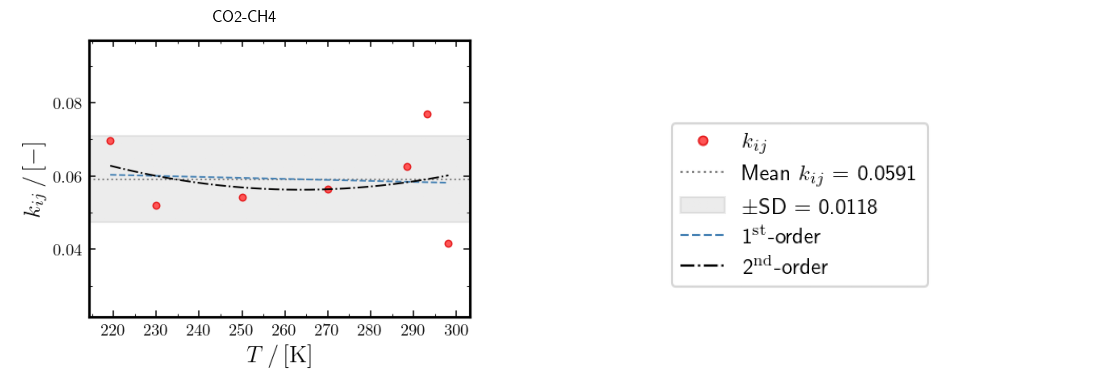

|component|molarweight|m|sigma|epsilon_k|
|-|-|-|-|-|
|carbon dioxide|43.99|2.53096|2.57855|153.31864|
|methane|16.031|1.0|3.70051|150.07147|

|component 1|component 2|k_ij|
|-|-|-|
|carbon dioxide|methane|0.0|

In [5]:
KIJ_PAIRS_FILE = Path("CSV_feeds/KIJ_pairs.json")
KIJ_LABELS = RegistryManager.kij_labels_from_names(COMPONENTS)

with open(KIJ_PAIRS_FILE) as f:
    kij_overrides = json.load(f)

KIJ_map = {}
for pair in combinations(KIJ_LABELS, 2):
    pair_key = f"{pair[0]}-{pair[1]}"
    alt_key = f"{pair[1]}-{pair[0]}"
    KIJ_map[pair] = kij_overrides.get(pair_key, kij_overrides.get(alt_key, "zero"))

print(f"Loaded KIJ models from {KIJ_PAIRS_FILE}")

feeds       = CompositionHandler.make_feeds(*compositions)

# Filter out components with zero composition across ALL feeds
all_z = np.array(feeds)
active_mask = np.any(all_z > 0, axis=0)
ACTIVE_COMPONENTS = [c for c, m in zip(COMPONENTS, active_mask) if m]
ACTIVE_KIJ_LABELS = RegistryManager.kij_labels_from_names(ACTIVE_COMPONENTS)
active_map = ParameterBuilder.reduce_kij_map(ACTIVE_COMPONENTS, KIJ_map)

print(f"Active components (non-zero in at least one feed): {ACTIVE_COMPONENTS}")

builder     = KIJ.KIJMatrixBuilder(root=str(KIJ_DIR),kij_filename="KIJ.json",verbose=False)
parameters  = ParameterBuilder.build_parameters(ACTIVE_COMPONENTS,T_K=300.0,kij_builder=builder,model_map=active_map)
components  = RegistryManager.get_component_names(parameters)
builder.build_and_display(components=ACTIVE_KIJ_LABELS,model_map=active_map,T_eval=300.0,
                                        show_matrix=True,show_pair_equations=True)
builder.show_pair_plots(ACTIVE_KIJ_LABELS, mode="all")

parameters

In [6]:
if SLURM_RUN == False:
    T_initial   = 200
    P_TOL       = 1e-2          # Pressure [bar] tolerance for flash calculations
    T_STEP      = 10            # Temperature step for bubble/dew curves [K]
    P_STEP      = 5             # Pressure step for flash calculations [bar]
    lgrid       = 100           # Length of computational domain [Angstrom]
    ngrid       = 500           # Number of grid points for planar interface
    PT_results  = {}            # Store phase envelope results
    VLE_DFT     = {}            # Store VLE-DFT combined results
    
elif SLURM_RUN == True:
    T_initial   = 200
    P_TOL       = 1e-4           
    T_STEP      = 5            
    P_STEP      = 2                 
    lgrid       = 100          
    ngrid       = 2048
    PT_results  = {}       
    VLE_DFT     = {}    

In [7]:
# Parameters & EOS (T-dependent kij rebuilt per temperature)

for k, z in enumerate(feeds, start=1):
    
    # --- Normalize + mole amounts ---
    z = CompositionHandler.normalize_z(z)
    feed = CompositionHandler.compute_feed_moles(z)
    
    if verbose:
        print(f"\nFeed {k}: z = {z}")
    
    # --- Detect zero components and reduce if needed ---
    active_z, active_components, is_reduced = CompositionHandler.reduce_components(
        z, COMPONENTS, verbose=verbose
    )
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)
    
    # --- Critical point (use reference T for kij) ---
    parameters_ref = ParameterBuilder.build_parameters(
        active_components,
        T_K=T_initial,
        kij_builder=builder,
        model_map=active_map
    )
    eos = feos.HelmholtzEnergyFunctional.pcsaft(parameters_ref)
    
    try:
        CT, CP = VLECalculator.compute_critical_point(eos, active_z, T_guess=T_initial)
        
        if verbose:
            print(f"Critical Point: T = {CT/si.KELVIN:.2f} K, P = {CP/si.BAR:.2f} bar")
        
        # Compute bubble and dew curves with T-dependent kij
        T_values = range(int(T_initial), int(CT / si.KELVIN) + 1, T_STEP)
        
        T_bubble_all, P_bubble_all = [], []
        T_dew_all, P_dew_all = [], []
        
        for T_K in T_values:
            # Rebuild parameters and eos at each temperature
            parameters_T = ParameterBuilder.build_parameters(
                active_components,
                T_K=float(T_K),
                kij_builder=builder,
                model_map=active_map
            )
            eos_T = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
            
            # Compute bubble and dew curves
            T_bub, P_bub = VLECalculator.compute_bubble_curve(eos_T, [T_K], active_feed, verbose=verbose)
            T_dew, P_dew = VLECalculator.compute_dew_curve(eos_T, [T_K], active_feed, verbose=verbose)
            
            T_bubble_all.extend(T_bub)
            P_bubble_all.extend(P_bub)
            T_dew_all.extend(T_dew)
            P_dew_all.extend(P_dew)
        
        # Store results
        PT_results[f"feed_{k}"] = {
            "z": [round(float(x), 6) for x in np.asarray(z, dtype=float)],
            "TC_K": round(float(CT / si.KELVIN), 2),
            "PC_bar": round(float(CP / si.BAR), 2),
            "bubble": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_bubble_all, P_bubble_all)],
            "dew": [{"T_K": float(T), "P_bar": float(P)} for T, P in zip(T_dew_all, P_dew_all)],
        }
    
    except Exception as e:
        print(f"Feed {k}: z = {z}")
        print("Critical point computation failed:", e)

## PT Diagram Plot, TP Flash, and cDFT Calculations

Available feeds: ['feed_1']
feed_1: 20 bubble pts, 20 dew pts, 20 isotherms, 200 interfacial pts


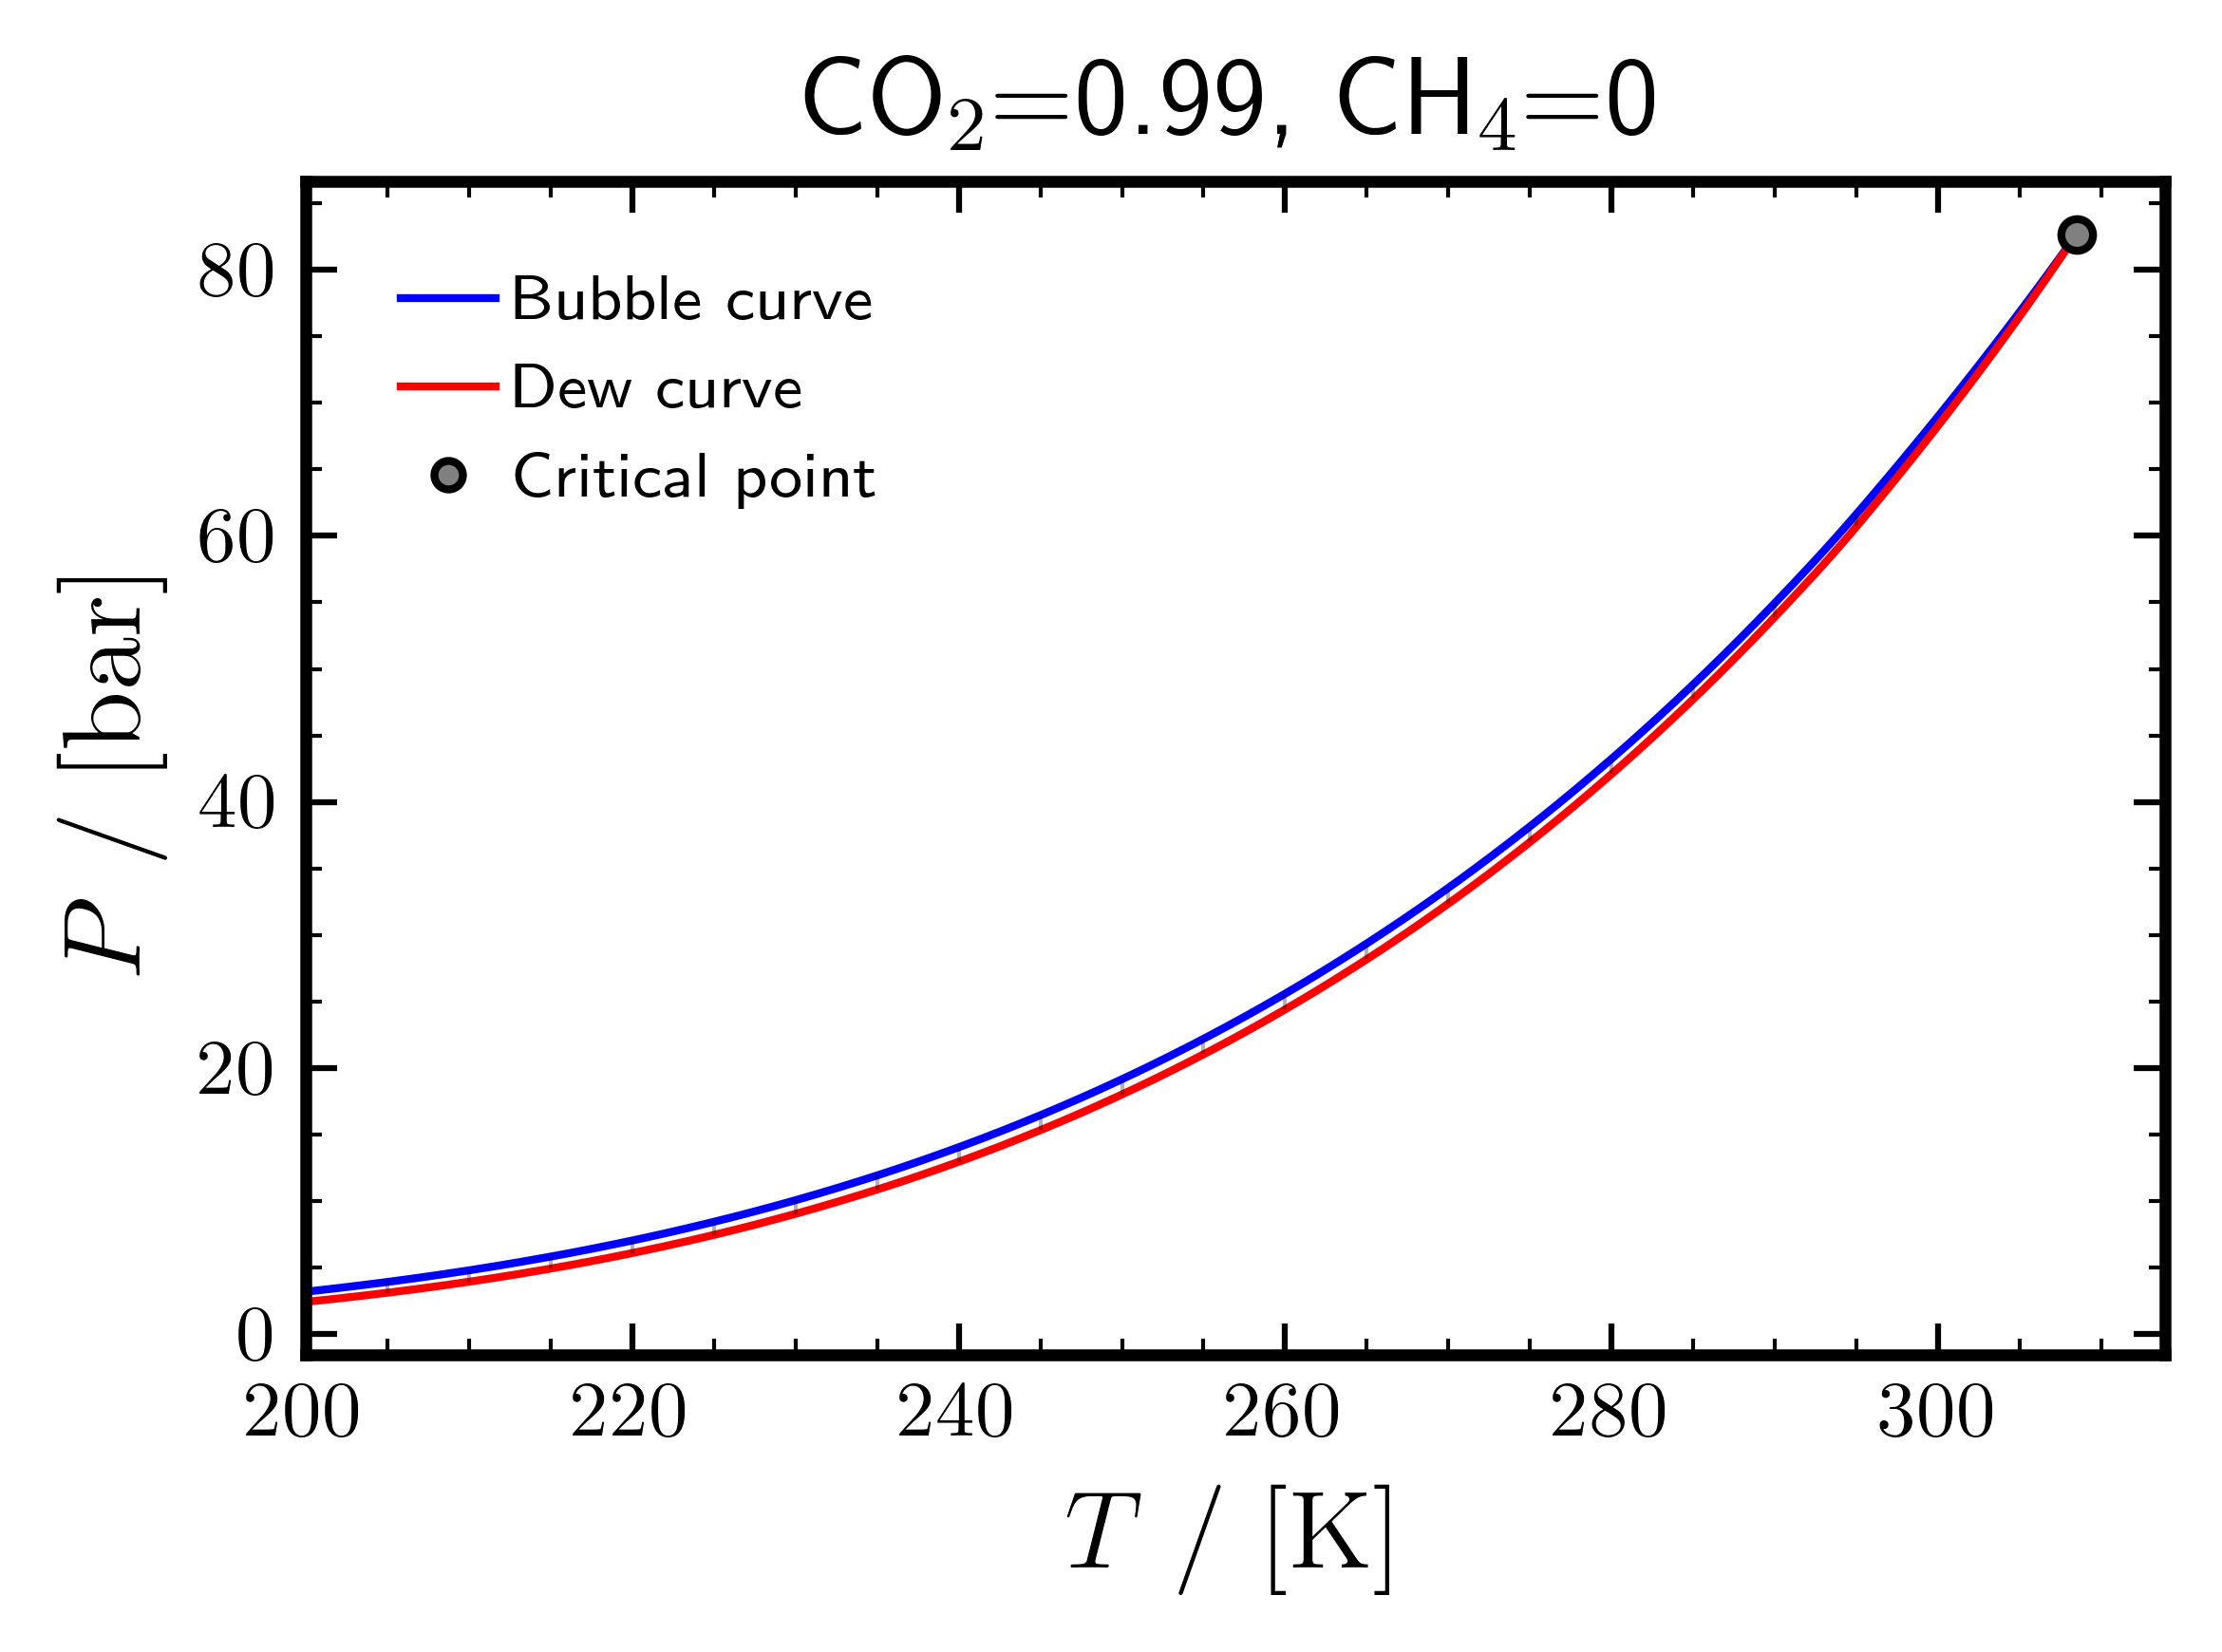

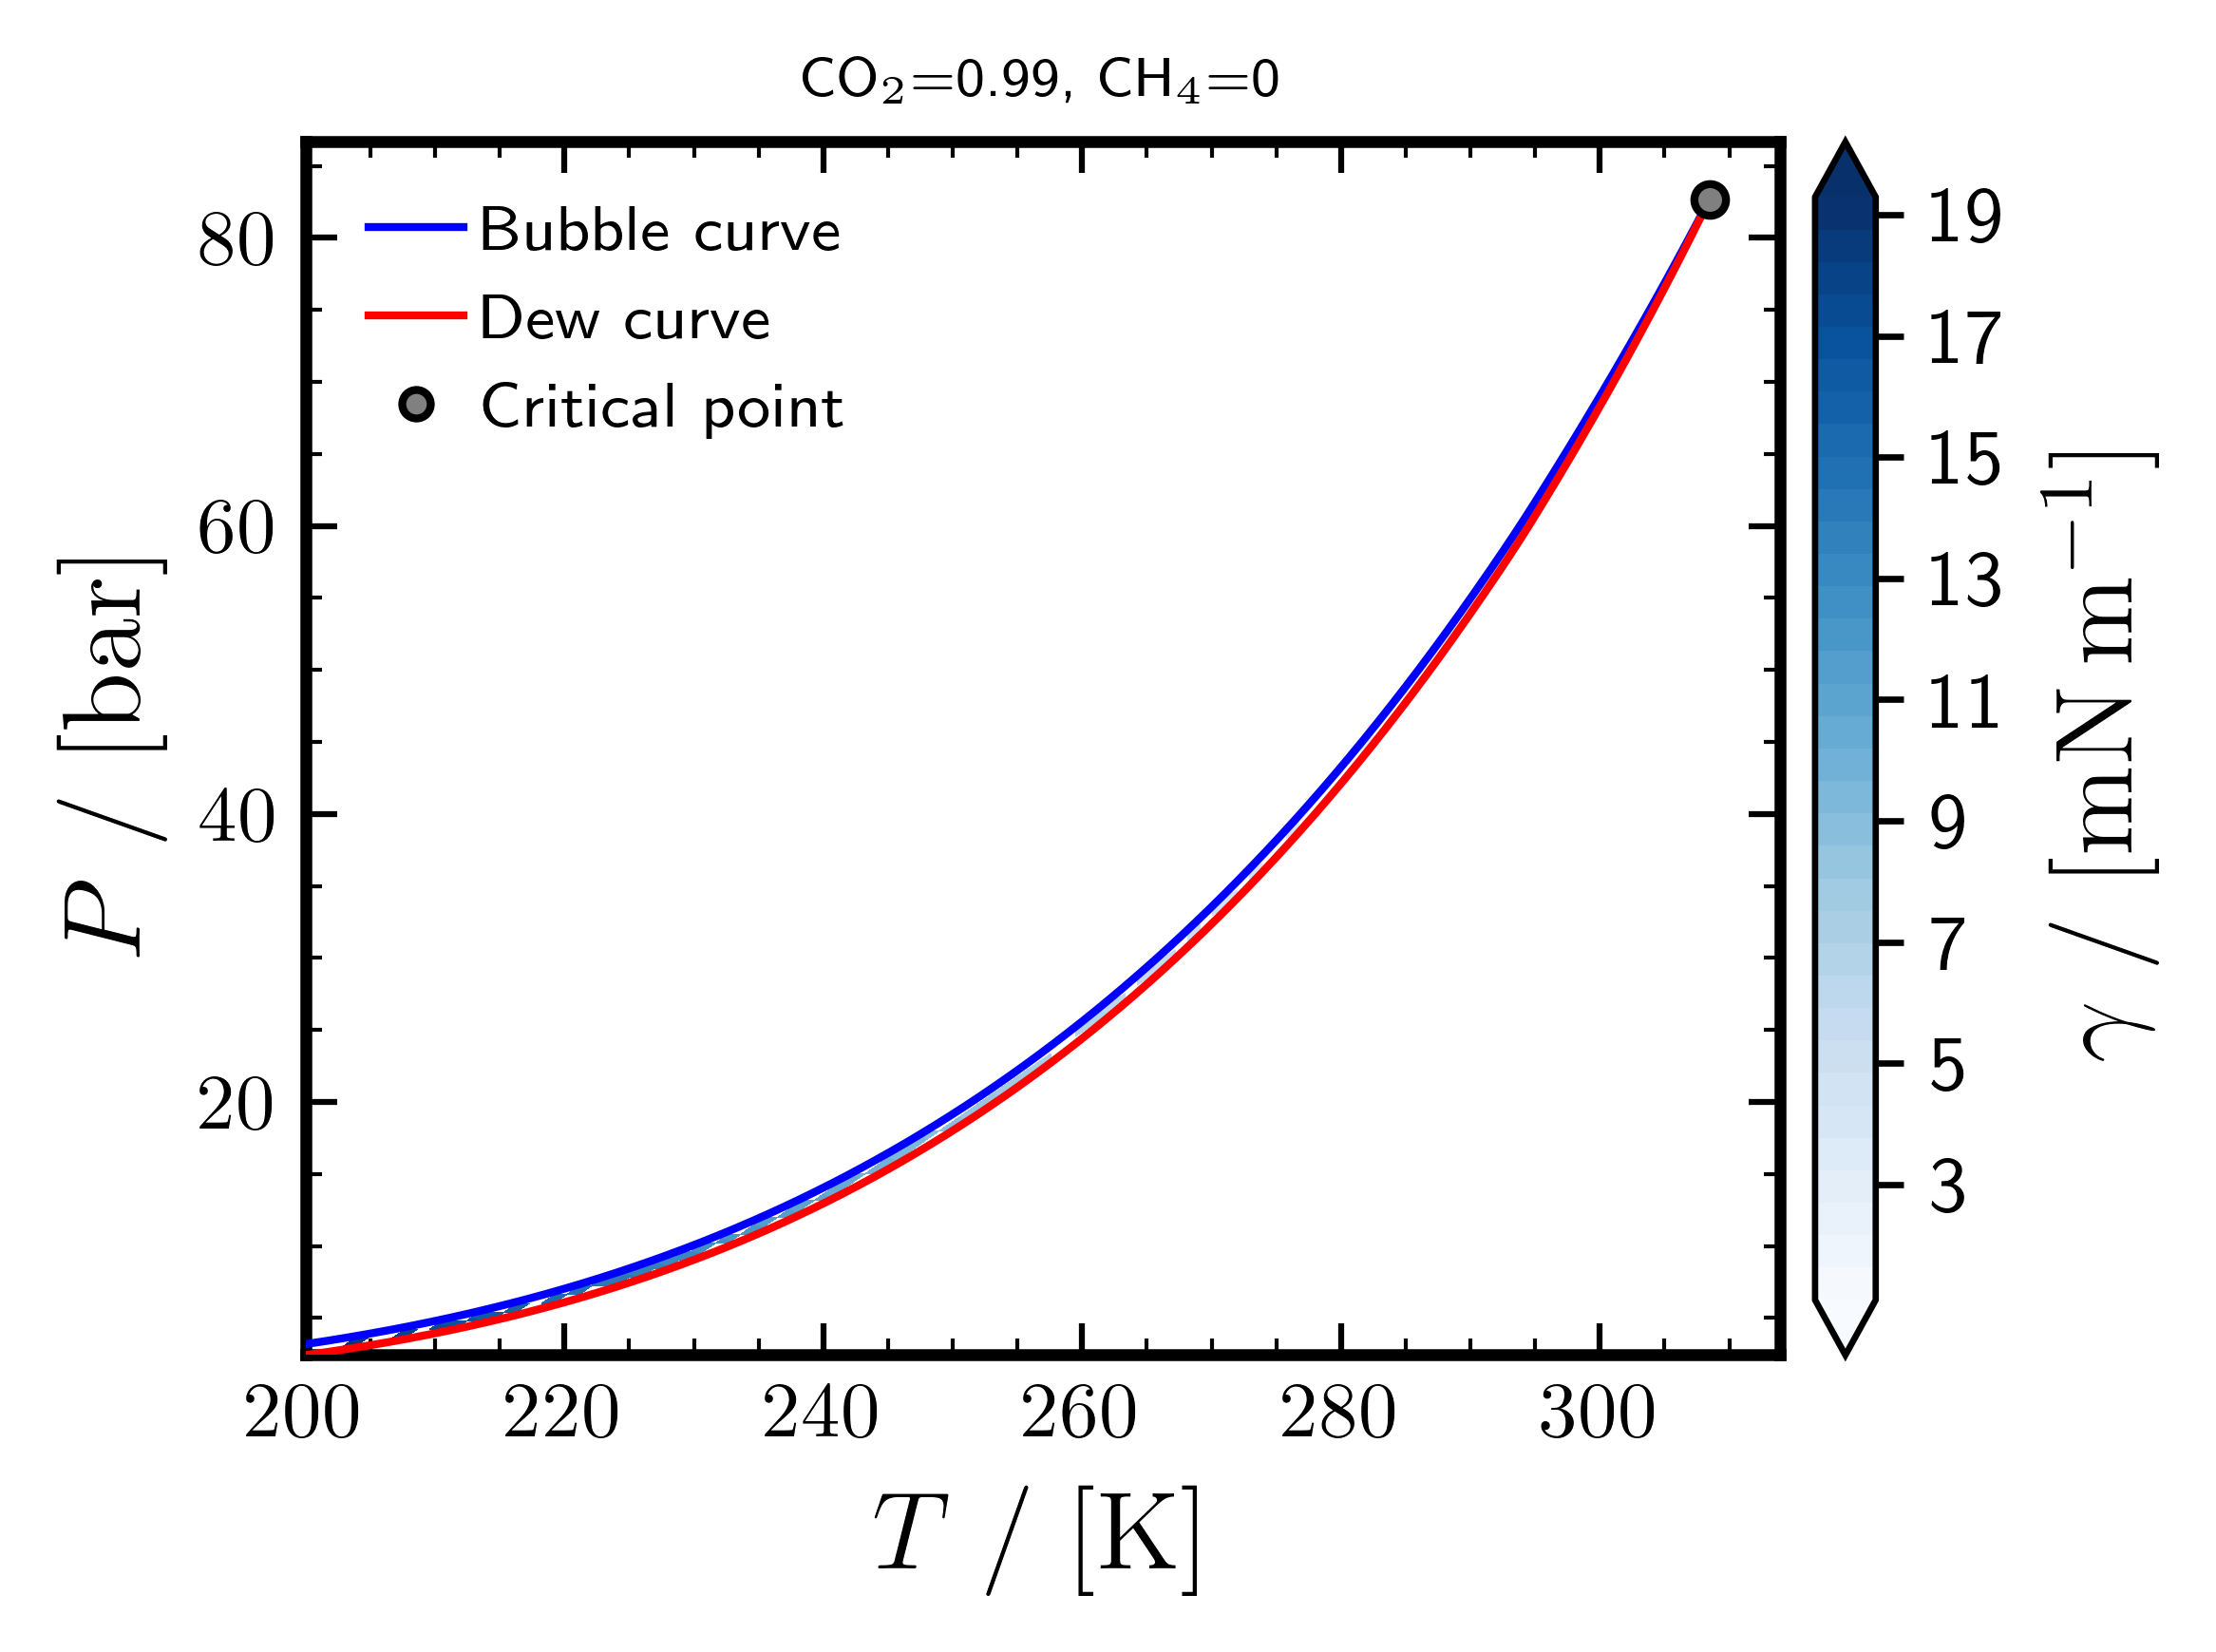

In [8]:
# PT phase diagram space sweep, TP flash, and cDFT computations

# Pure CO2 property calculator (reused across all feeds/temperatures)
sec = semi_emperical_correlations(n_grid=ngrid, l_grid=lgrid)

for feed_key, feed in PT_results.items():
    
    TP_z = np.array(feed.get("z", []))
    CT = feed["TC_K"] * si.KELVIN
    CP = feed["PC_bar"] * si.BAR
    
    # --- Detect zero components and reduce if needed ---
    active_z, active_components, is_reduced = CompositionHandler.reduce_components(
        TP_z, COMPONENTS, verbose=verbose
    )
    active_feed = CompositionHandler.compute_feed_moles(active_z)
    active_map = ParameterBuilder.reduce_kij_map(active_components, KIJ_map)
    
    # --- Plot phase diagram using PlottingEngine ---
    fig, ax = PlottingEngine.plot_phase_diagram(PT_results, feed_key, parameters)
    
    # Prepare bubble/dew dictionaries
    bub = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("bubble", [])}
    dew = {int(round(pt["T_K"])): float(pt["P_bar"]) for pt in feed.get("dew", [])}
    common_T = sorted(set(bub) & set(dew))
    
    # Initialize unified storage for this feed composition
    VLE_DFT[feed_key] = {
        "z": TP_z.tolist(),
        "phase_envelope": {
            "bubble_curve": [{"T_K": T, "P_bar": bub[T]} for T in sorted(bub.keys())],
            "dew_curve": [{"T_K": T, "P_bar": dew[T]} for T in sorted(dew.keys())],
            "isothermal_lines": [
                {"T_K": T, "P_bubble_bar": bub[T], "P_dew_bar": dew[T]}
                for T in common_T
            ]
        },
        "interfacial_data": {}
    }
    
    if verbose:
        print(f"\n{feed_key}:")
        for T in common_T:
            print(f"  T = {T} K: P_bubble = {bub[T]:.2f} bar, P_dew = {dew[T]:.2f} bar")
    
    if common_T:
        for T in common_T:
            
            # Rebuild parameters and eos at this temperature
            parameters_T = ParameterBuilder.build_parameters(
                active_components,
                T_K=float(T),
                kij_builder=builder,
                model_map=active_map
            )
            eos_T = feos.HelmholtzEnergyFunctional.pcsaft(parameters_T)
            molar_masses = PropertyCalculator.molar_masses(parameters_T)  # g/mol
            
            # --- Pure CO2 properties at this temperature ---
            gamma0_CO2, rhoL0_CO2, rhoV0_CO2, Tc_CO2, Psat_CO2 = \
                sec._pure_component_cDFT("carbon dioxide", float(T))
            
            P_b = bub[T]
            P_d = dew[T]
            
            if P_b >= P_d:
                
                pressures = np.linspace(P_d + P_TOL, P_b - P_TOL, 10)
                
                # Plot isothermal line on PT diagram
                ax.plot([T, T], [P_d, P_b], linewidth=0.5, linestyle="--", color="k", alpha=0.3)
                
                # Initialize list for this temperature
                VLE_DFT[feed_key]["interfacial_data"][T] = []
                
                for P in pressures:
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} | z = {active_z}")
                    
                    # --- TP flash using VLECalculator ---
                    try:
                        eq, x, y, liquid_density, vapor_density = VLECalculator.tp_flash(
                            eos_T, T*si.KELVIN, P*si.BAR, active_z*si.MOL, molar_masses)
                    except Exception as e:
                        print(f"TP flash failed for z = {active_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        continue
                    
                    # --- Planar interface & surface tension using InterfacialTensionCalculator ---
                    interface = InterfacialTensionCalculator.build_planar_interface(
                        eq, critical_temperature=CT, n_grid=ngrid, l_grid=lgrid)
                    
                    try:
                        gamma_mN_m, interfacial_thickness_nm, enrichment = \
                            InterfacialTensionCalculator.solve_interface_properties(interface)
                    except Exception as e:
                        print(f"Surface tension calculation failed for z = {active_z} at T = {T} K, P = {P:.2f} bar: {e}")
                        gamma_mN_m = np.nan
                        interfacial_thickness_nm = np.nan
                        enrichment = tuple(np.nan for _ in active_components)
                    
                    if verbose:
                        print(f"T = {T} K | P_flash = {P:.2f} bar | gamma = {gamma_mN_m:.6f} mN/m")
                    
                    # --- Use DataProcessor.assemble_row for consistent formatting ---
                    row_data = DataProcessor.assemble_row(
                        T, P, active_z, CT, CP, P_b, P_d, liquid_density, vapor_density,
                        x, y, gamma_mN_m, interfacial_thickness_nm, active_components, enrichment,
                        gamma0_CO2=gamma0_CO2,
                        rhoL0_CO2_mol_cm3=rhoL0_CO2,
                        rhoV0_CO2_mol_cm3=rhoV0_CO2,
                        Tc_CO2=Tc_CO2,
                        Psat_CO2=Psat_CO2,
                        ML_mode=True)
                    
                    # Store in interfacial_data
                    VLE_DFT[feed_key]["interfacial_data"][T].append(row_data)
    
    PlottingEngine.save_plots(fig, f"PT_{feed_key}", folder=PLOT_FOLDER)
    
    fig_gamma = PlottingEngine.plot_interfacial_tension_map(PT_results, VLE_DFT, feed_key, parameters)
    
    if fig_gamma is not None:
        PlottingEngine.save_plots(fig_gamma, f"Gamma_{feed_key}", folder=PLOT_FOLDER)

summary = DataProcessor.summarize_vle_dft(VLE_DFT)

if verbose:
    print(summary)

saved_files = DataProcessor.export_to_csv(VLE_DFT, folder=CSV_FOLDER, verbose=verbose)

In [9]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.70 minutes
